# Diagnóstico de Diabetes com Machine Learning

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

O diabetes é uma das doenças crônicas mais prevalentes no mundo, afetando centenas de milhões de pessoas. A detecção precoce é fundamental para prevenir complicações graves como problemas cardiovasculares, renais e de visão. Neste notebook, vamos construir modelos de Machine Learning para prever se uma paciente tem ou não diabetes, com base em dados clínicos.

### Dataset

Utilizaremos o **Pima Indians Diabetes Dataset**, originalmente do National Institute of Diabetes and Digestive and Kidney Diseases. O dataset contém 768 amostras de pacientes do sexo feminino com pelo menos 21 anos de idade, da herança Pima Indian. São 8 features clínicas e 1 variável alvo (Outcome).

**Fonte:** https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data

### Objetivo

Treinar e comparar modelos de classificação para identificar pacientes com diabetes, destacando que o modelo é uma ferramenta de apoio — **a decisão final é sempre do médico**.

---

## 1. Importação das Bibliotecas

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import os

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelos e métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Modelos de classificação (diferentes do notebook anterior para mostrar variedade)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# SHAP para interpretabilidade
import shap

# Importar nossas funções auxiliares
import sys
sys.path.append('..')
from src.utils import (
    plotar_distribuicao_classes, plotar_histogramas, plotar_correlacao,
    plotar_matriz_confusao, plotar_curvas_roc_comparativas,
    avaliar_modelo, comparar_modelos, exibir_classification_report
)

# Configurações
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Diretório para salvar os resultados (gráficos e tabelas)
DIR_RESULTADOS = os.path.join('..', 'resultados')
os.makedirs(DIR_RESULTADOS, exist_ok=True)
print(f"Gráficos serão salvos em: {os.path.abspath(DIR_RESULTADOS)}")

Gráficos serão salvos em: /home/neto/projects/fiap/ai4devs/FASE_1/tech-challenge/resultados


## 2. Carregamento e Exploração dos Dados (EDA)

### 2.1 Carregamento do Dataset

In [3]:
# Carregar o dataset de diabetes a partir do CSV
# O CSV foi gerado pelo script data/download_datasets.py
# Fonte original: https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data

caminho_csv = os.path.join('..', 'data', 'diabetes.csv')

# Se o CSV ainda não existe, rodar o script de download
if not os.path.exists(caminho_csv):
    print("CSV não encontrado. Executando script de download...")
    sys.path.append(os.path.join('..', 'data'))
    from download_datasets import baixar_diabetes
    baixar_diabetes()

# Carregar o CSV
df = pd.read_csv(caminho_csv)

print(f"Dataset carregado de: {caminho_csv}")
print(f"Formato: {df.shape[0]} amostras e {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
print(f"\nDescrição das features:")
print("  - Pregnancies: Número de gestações")
print("  - Glucose: Concentração de glicose no sangue (teste de tolerância à glicose)")
print("  - BloodPressure: Pressão arterial diastólica (mm Hg)")
print("  - SkinThickness: Espessura da dobra cutânea do tríceps (mm)")
print("  - Insulin: Insulina sérica de 2 horas (mu U/ml)")
print("  - BMI: Índice de massa corporal (kg/m²)")
print("  - DiabetesPedigreeFunction: Função de pedigree de diabetes")
print("  - Age: Idade (anos)")
print("  - Outcome: 0 = Não diabético, 1 = Diabético")
print()
df.head()

Dataset carregado de: ../data/diabetes.csv
Formato: 768 amostras e 9 colunas

Colunas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Descrição das features:
  - Pregnancies: Número de gestações
  - Glucose: Concentração de glicose no sangue (teste de tolerância à glicose)
  - BloodPressure: Pressão arterial diastólica (mm Hg)
  - SkinThickness: Espessura da dobra cutânea do tríceps (mm)
  - Insulin: Insulina sérica de 2 horas (mu U/ml)
  - BMI: Índice de massa corporal (kg/m²)
  - DiabetesPedigreeFunction: Função de pedigree de diabetes
  - Age: Idade (anos)
  - Outcome: 0 = Não diabético, 1 = Diabético



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2.2 Informações Gerais e Estatísticas Descritivas

In [4]:
# Informações gerais
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
df.info()
print()

# Estatísticas descritivas
df.describe()

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.3 Identificando Valores Problemáticos (Zeros Impossíveis)

Olhando as estatísticas descritivas, podemos notar algo estranho: **o valor mínimo de algumas colunas é 0**. Isso é biologicamente impossível para variáveis como Glucose (glicose), BloodPressure (pressão arterial) e BMI (índice de massa corporal). Uma pessoa viva não pode ter glicose ou pressão arterial igual a zero!

Esses zeros provavelmente representam **dados faltantes** que foram registrados como 0 no dataset original. Precisamos tratar isso antes de treinar os modelos.

In [5]:
# Colunas onde zero é biologicamente impossível
colunas_com_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("ZEROS IMPOSSÍVEIS - Contagem por coluna")
print("=" * 50)
for coluna in colunas_com_zeros:
    zeros = (df[coluna] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {coluna:30s}: {zeros:3d} zeros ({pct:.1f}%)")

print(f"\nTotal de amostras: {len(df)}")
print("\nNota: Pregnancies pode ter zero (sem gestações) e Outcome é a variável alvo.")

ZEROS IMPOSSÍVEIS - Contagem por coluna
  Glucose                       :   5 zeros (0.7%)
  BloodPressure                 :  35 zeros (4.6%)
  SkinThickness                 : 227 zeros (29.6%)
  Insulin                       : 374 zeros (48.7%)
  BMI                           :  11 zeros (1.4%)

Total de amostras: 768

Nota: Pregnancies pode ter zero (sem gestações) e Outcome é a variável alvo.


### 2.4 Distribuição das Classes

  → Gráfico salvo em: ../resultados/db_distribuicao_classes.png


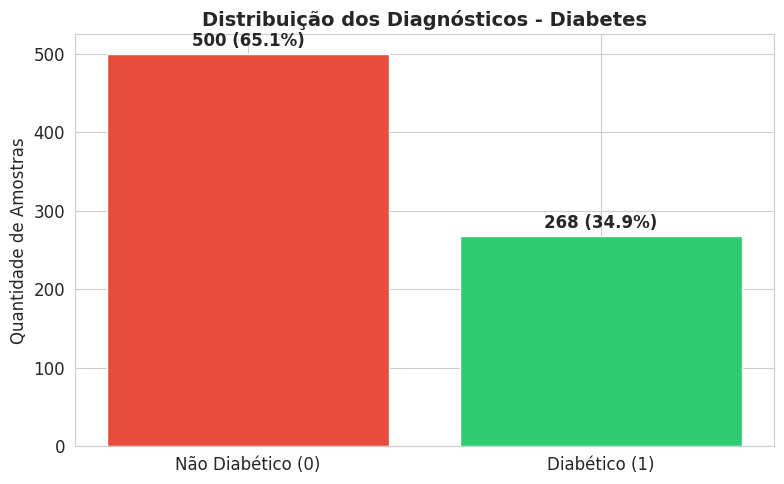

Proporção das classes:
  Não Diabético: 500 (65.1%)
  Diabético:     268 (34.9%)


In [6]:
# Distribuição das classes
plotar_distribuicao_classes(
    df['Outcome'],
    nomes_classes=['Não Diabético (0)', 'Diabético (1)'],
    titulo='Distribuição dos Diagnósticos - Diabetes',
    salvar_em=os.path.join(DIR_RESULTADOS, 'db_distribuicao_classes.png')
)

print(f"Proporção das classes:")
print(f"  Não Diabético: {(df['Outcome'] == 0).sum()} ({(df['Outcome'] == 0).mean()*100:.1f}%)")
print(f"  Diabético:     {(df['Outcome'] == 1).sum()} ({(df['Outcome'] == 1).mean()*100:.1f}%)")

**Análise:** O dataset apresenta desbalanceamento (aproximadamente 65% não diabéticos e 35% diabéticos). Vamos usar `stratify` na separação dos dados para manter essa proporção.

### 2.5 Distribuição das Features

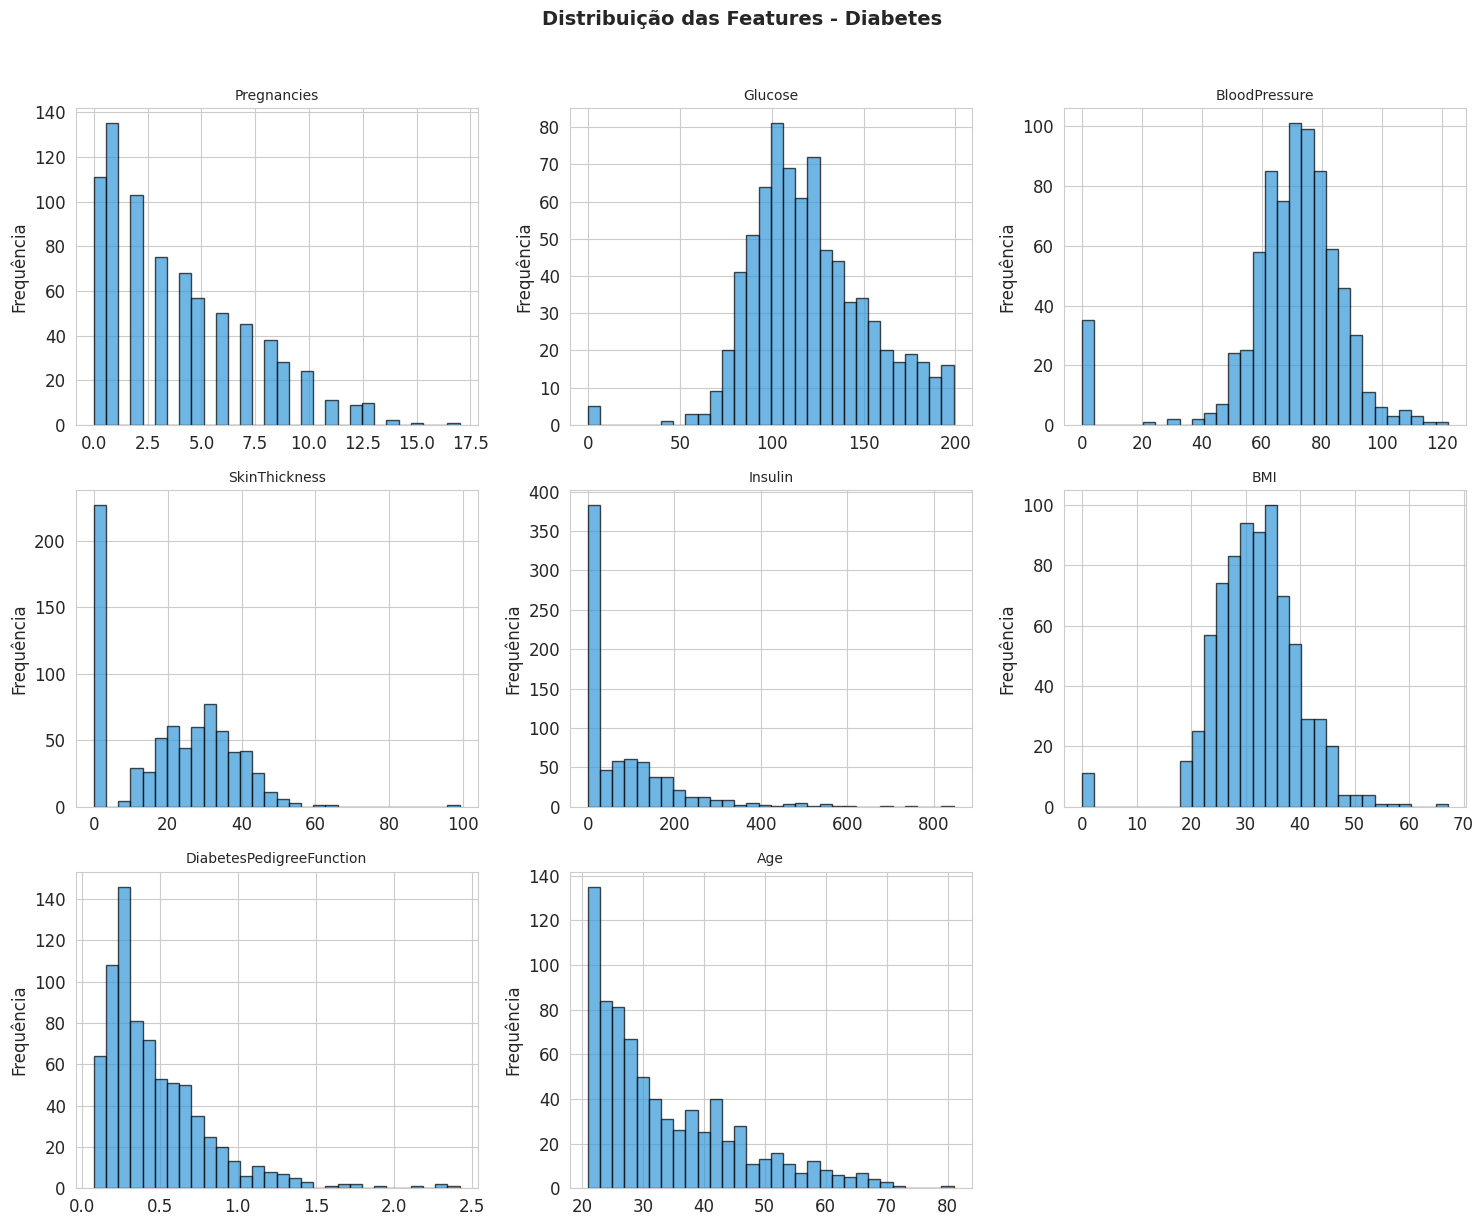

In [7]:
# Histogramas de todas as features
features = [col for col in df.columns if col != 'Outcome']
plotar_histogramas(df, features, titulo='Distribuição das Features - Diabetes')

  → Gráfico salvo em: ../resultados/db_boxplots.png


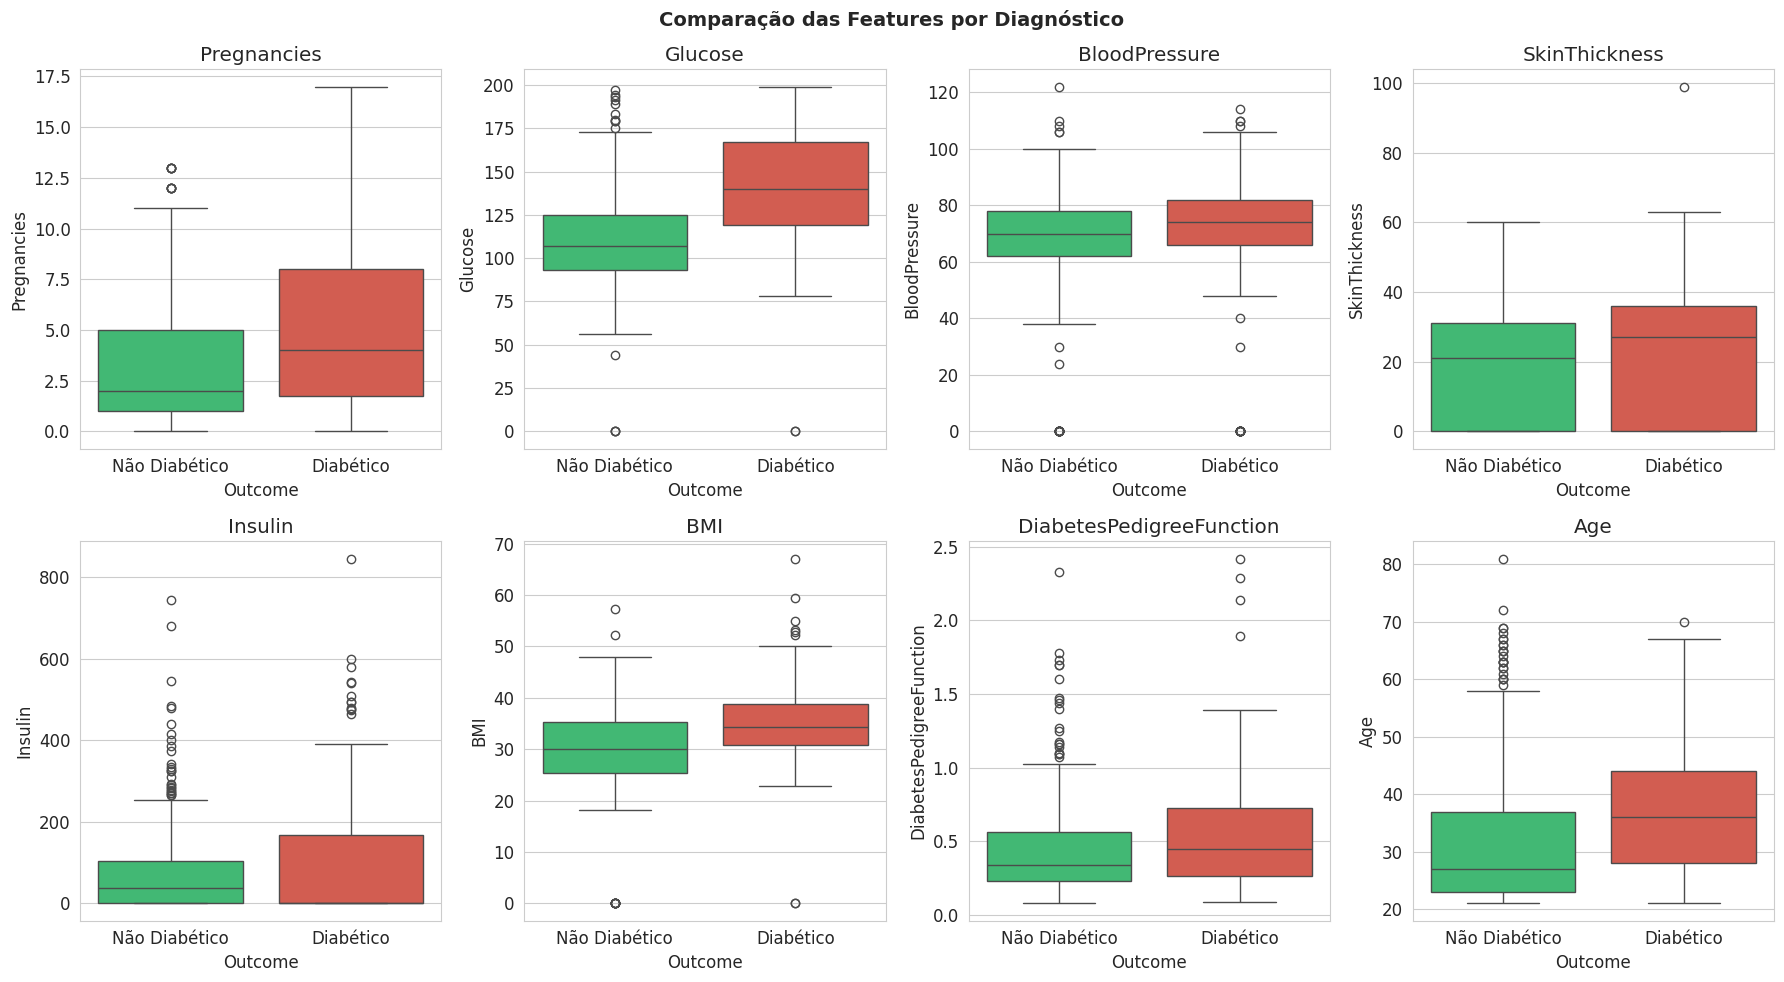

In [8]:
# Boxplots comparando diabéticos vs não diabéticos
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='Outcome', y=feature, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_xticklabels(['Não Diabético', 'Diabético'])
    axes[i].set_title(feature)

fig.suptitle('Comparação das Features por Diagnóstico', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'db_boxplots.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'db_boxplots.png')}")
plt.show()

**Análise dos boxplots:** Podemos observar que pacientes diabéticos tendem a ter valores mais altos de Glucose, BMI e Age. A feature Glucose apresenta a separação mais clara entre as classes, o que faz sentido clinicamente — glicose elevada é um dos principais indicadores de diabetes.

---

## 3. Pré-processamento dos Dados

### 3.1 Tratamento dos Zeros Impossíveis

Vamos substituir os zeros impossíveis por NaN e depois imputar os valores faltantes. Mas qual estratégia de imputação usar? Vamos comparar duas abordagens:
- **Média**: substituir pelo valor médio da coluna
- **Mediana**: substituir pelo valor mediano da coluna

A mediana é geralmente mais robusta a outliers, mas vamos testar para confirmar.

In [9]:
# Substituir zeros por NaN nas colunas onde zero é impossível
df_tratado = df.copy()
for coluna in colunas_com_zeros:
    df_tratado[coluna] = df_tratado[coluna].replace(0, np.nan)

print("Valores nulos após substituição dos zeros:")
print(df_tratado.isnull().sum().to_string())
print(f"\nTotal de valores nulos: {df_tratado.isnull().sum().sum()}")

Valores nulos após substituição dos zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0

Total de valores nulos: 652


In [10]:
# Comparar imputação por média vs mediana
# Para isso, vamos criar duas versões do dataset e testar com um modelo simples

# Versão 1: imputação por média
df_media = df_tratado.copy()
for coluna in colunas_com_zeros:
    df_media[coluna].fillna(df_media[coluna].mean(), inplace=True)

# Versão 2: imputação por mediana
df_mediana = df_tratado.copy()
for coluna in colunas_com_zeros:
    df_mediana[coluna].fillna(df_mediana[coluna].median(), inplace=True)

# Comparar média e mediana para cada coluna
print("COMPARAÇÃO: Valores usados para imputação")
print("=" * 60)
print(f"{'Coluna':30s} {'Média':>10s} {'Mediana':>10s}")
print("-" * 60)
for coluna in colunas_com_zeros:
    media_val = df_tratado[coluna].mean()
    mediana_val = df_tratado[coluna].median()
    print(f"{coluna:30s} {media_val:10.2f} {mediana_val:10.2f}")

# Testar qual funciona melhor com validação cruzada
from sklearn.tree import DecisionTreeClassifier

X_media = df_media.drop('Outcome', axis=1)
X_mediana = df_mediana.drop('Outcome', axis=1)
y_temp = df_media['Outcome']

pipeline_media = Pipeline([('scaler', StandardScaler()), ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))])
pipeline_mediana = Pipeline([('scaler', StandardScaler()), ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))])

scores_media = cross_val_score(pipeline_media, X_media, y_temp, cv=5, scoring='f1')
scores_mediana = cross_val_score(pipeline_mediana, X_mediana, y_temp, cv=5, scoring='f1')

print(f"\nF1-Score com imputação por MÉDIA:   {scores_media.mean():.4f} (+/- {scores_media.std():.4f})")
print(f"F1-Score com imputação por MEDIANA: {scores_mediana.mean():.4f} (+/- {scores_mediana.std():.4f})")

if scores_mediana.mean() >= scores_media.mean():
    df_final = df_mediana.copy()
    print("\n→ Imputação por MEDIANA selecionada (mais robusta a outliers)")
else:
    df_final = df_media.copy()
    print("\n→ Imputação por MÉDIA selecionada")

COMPARAÇÃO: Valores usados para imputação
Coluna                              Média    Mediana
------------------------------------------------------------
Glucose                            121.69     117.00
BloodPressure                       72.41      72.00
SkinThickness                       29.15      29.00
Insulin                            155.55     125.00
BMI                                 32.46      32.30

F1-Score com imputação por MÉDIA:   0.6336 (+/- 0.0571)
F1-Score com imputação por MEDIANA: 0.6498 (+/- 0.0395)

→ Imputação por MEDIANA selecionada (mais robusta a outliers)


### 3.2 Análise de Correlação

  → Gráfico salvo em: ../resultados/db_correlacao.png


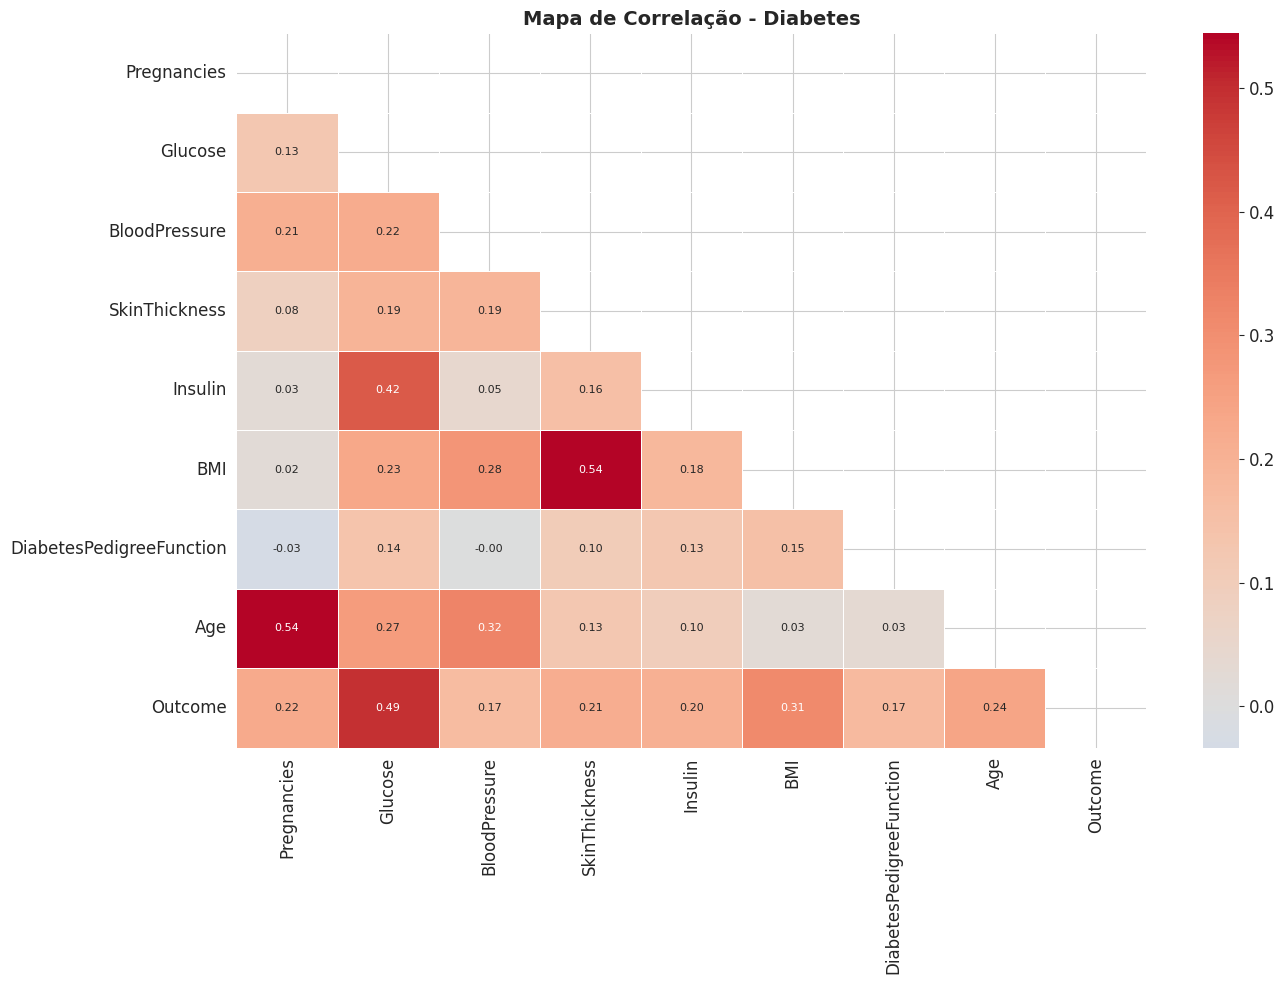

In [11]:
# Análise de correlação
correlacao = plotar_correlacao(df_final, titulo='Mapa de Correlação - Diabetes',
                        salvar_em=os.path.join(DIR_RESULTADOS, 'db_correlacao.png'))

In [12]:
# Correlação com a variável alvo (Outcome)
corr_com_outcome = df_final.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)

print("Correlação das features com Outcome (Diabetes):")
print("=" * 50)
for feature, corr in corr_com_outcome.items():
    barra = "█" * int(abs(corr) * 50)
    print(f"  {feature:30s}: {corr:+.3f} {barra}")

print("\n→ Glucose tem a maior correlação com diabetes, seguida por BMI e Age.")

Correlação das features com Outcome (Diabetes):
  Glucose                       : +0.493 ████████████████████████
  BMI                           : +0.312 ███████████████
  Age                           : +0.238 ███████████
  Pregnancies                   : +0.222 ███████████
  SkinThickness                 : +0.215 ██████████
  Insulin                       : +0.204 ██████████
  DiabetesPedigreeFunction      : +0.174 ████████
  BloodPressure                 : +0.166 ████████

→ Glucose tem a maior correlação com diabetes, seguida por BMI e Age.


**Análise da correlação:** Diferente do dataset de câncer de mama, aqui não temos features com correlação muito alta entre si. Isso é bom, pois indica que cada feature traz informação complementar. A Glucose é claramente a feature mais correlacionada com o diagnóstico de diabetes.

### 3.3 Separação dos Dados e Feature Scaling

In [13]:
# Separar features e variável alvo
X = df_final.drop('Outcome', axis=1)
y = df_final['Outcome']

# Divisão treino/teste (80/20) com estratificação
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_treino.shape[0]} amostras")
print(f"Conjunto de teste:  {X_teste.shape[0]} amostras")
print(f"\nProporção no treino - Diabético: {(y_treino == 1).mean()*100:.1f}%")
print(f"Proporção no teste  - Diabético: {(y_teste == 1).mean()*100:.1f}%")

# Escalonamento com StandardScaler
# Escolhemos StandardScaler pois os dados deste dataset não seguem uma distribuição uniforme
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print(f"\nEscalonamento aplicado com StandardScaler.")

Conjunto de treino: 614 amostras
Conjunto de teste:  154 amostras

Proporção no treino - Diabético: 34.9%
Proporção no teste  - Diabético: 35.1%

Escalonamento aplicado com StandardScaler.


---

## 4. Modelagem

Para este dataset, vamos usar três modelos diferentes (variando em relação ao notebook de câncer de mama):

1. **SVM (Support Vector Machine)** — busca encontrar o hiperplano que melhor separa as classes, maximizando a margem. Com kernel RBF, pode capturar relações não-lineares.

2. **KNN (K-Nearest Neighbors)** — já usado no notebook anterior, vamos usá-lo aqui também para comparar o desempenho entre os dois datasets.

3. **Árvore de Decisão** — novamente para termos a feature importance e podermos comparar quais features são importantes para cada problema.

### 4.1 Modelo 1: SVM (Support Vector Machine)

SVM (RBF) - Classification Report
               precision    recall  f1-score   support

Não Diabético       0.78      0.84      0.81       100
    Diabético       0.65      0.56      0.60        54

     accuracy                           0.74       154
    macro avg       0.71      0.70      0.70       154
 weighted avg       0.73      0.74      0.73       154

  → Gráfico salvo em: ../resultados/db_mc_svm.png


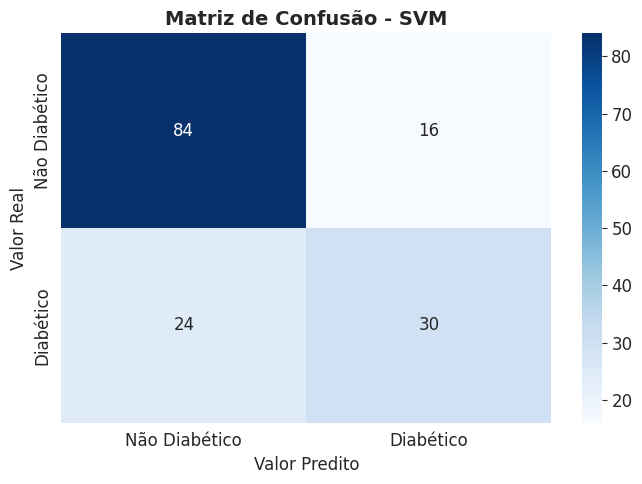

In [14]:
# Modelo 1: SVM com kernel RBF
# Usamos probability=True para poder gerar a curva ROC depois
modelo_svm = SVC(kernel='rbf', probability=True, random_state=42)
modelo_svm.fit(X_treino_scaled, y_treino)

# Predições
y_pred_svm = modelo_svm.predict(X_teste_scaled)
y_prob_svm = modelo_svm.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("SVM (RBF) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_svm, ['Não Diabético', 'Diabético'])

plotar_matriz_confusao(y_teste, y_pred_svm, ['Não Diabético', 'Diabético'],
                       titulo='Matriz de Confusão - SVM',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'db_mc_svm.png'))

### 4.2 Modelo 2: KNN

  → Gráfico salvo em: ../resultados/db_melhor_k.png


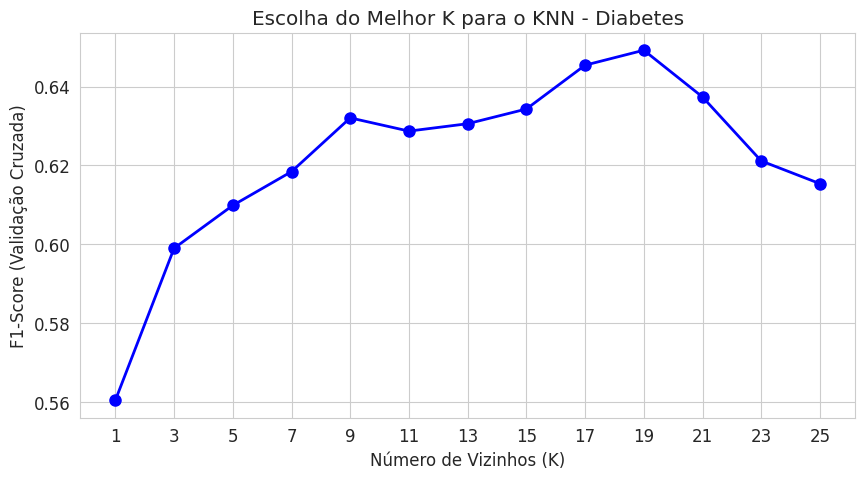

Melhor valor de K: 19 (F1-Score: 0.6492)


In [15]:
# Encontrar o melhor K
valores_k = range(1, 26, 2)
scores_k = []

for k in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_treino_scaled, y_treino, cv=5, scoring='f1')
    scores_k.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(list(valores_k), scores_k, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('F1-Score (Validação Cruzada)')
plt.title('Escolha do Melhor K para o KNN - Diabetes')
plt.xticks(list(valores_k))
plt.grid(True)
plt.savefig(os.path.join(DIR_RESULTADOS, 'db_melhor_k.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'db_melhor_k.png')}")
plt.show()

melhor_k = list(valores_k)[np.argmax(scores_k)]
print(f"Melhor valor de K: {melhor_k} (F1-Score: {max(scores_k):.4f})")

KNN (K=19) - Classification Report
               precision    recall  f1-score   support

Não Diabético       0.78      0.85      0.81       100
    Diabético       0.67      0.56      0.61        54

     accuracy                           0.75       154
    macro avg       0.72      0.70      0.71       154
 weighted avg       0.74      0.75      0.74       154

  → Gráfico salvo em: ../resultados/db_mc_knn.png


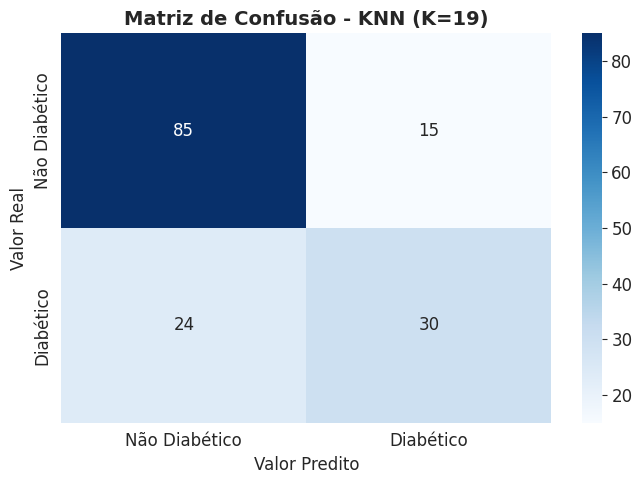

In [16]:
# Modelo 2: KNN com o melhor K
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_treino_scaled, y_treino)

y_pred_knn = modelo_knn.predict(X_teste_scaled)
y_prob_knn = modelo_knn.predict_proba(X_teste_scaled)[:, 1]

print(f"KNN (K={melhor_k}) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_knn, ['Não Diabético', 'Diabético'])

plotar_matriz_confusao(y_teste, y_pred_knn, ['Não Diabético', 'Diabético'],
                       titulo=f'Matriz de Confusão - KNN (K={melhor_k})',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'db_mc_knn.png'))

### 4.3 Modelo 3: Árvore de Decisão

ÁRVORE DE DECISÃO - Classification Report
               precision    recall  f1-score   support

Não Diabético       0.84      0.78      0.81       100
    Diabético       0.64      0.72      0.68        54

     accuracy                           0.76       154
    macro avg       0.74      0.75      0.74       154
 weighted avg       0.77      0.76      0.76       154

  → Gráfico salvo em: ../resultados/db_mc_arvore_decisao.png


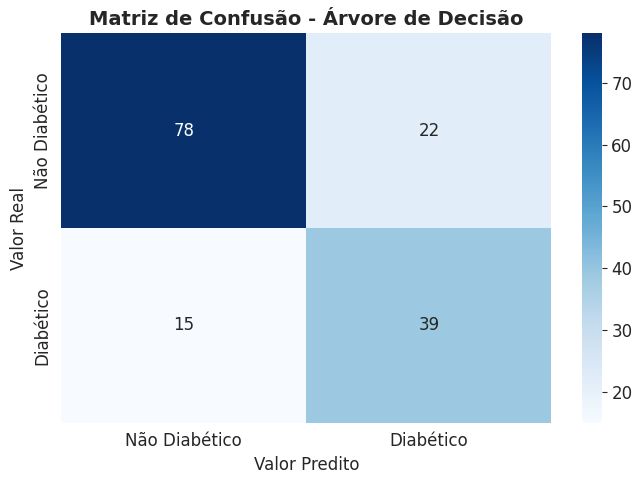

In [17]:
# Modelo 3: Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino_scaled, y_treino)

y_pred_arvore = modelo_arvore.predict(X_teste_scaled)
y_prob_arvore = modelo_arvore.predict_proba(X_teste_scaled)[:, 1]

print("ÁRVORE DE DECISÃO - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_arvore, ['Não Diabético', 'Diabético'])

plotar_matriz_confusao(y_teste, y_pred_arvore, ['Não Diabético', 'Diabético'],
                       titulo='Matriz de Confusão - Árvore de Decisão',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'db_mc_arvore_decisao.png'))

---

## 5. Avaliação Comparativa dos Modelos

### 5.1 Tabela Comparativa

**Sobre a escolha da métrica principal:** Para diabetes, o **F1-Score** é uma boa métrica de referência, pois busca um equilíbrio entre precisão e recall. Tanto falsos negativos (não diagnosticar diabetes) quanto falsos positivos (diagnosticar erroneamente) têm custos relevantes — o primeiro pode atrasar o tratamento, e o segundo pode gerar ansiedade e exames desnecessários.

In [18]:
# Tabela comparativa
metricas_svm = avaliar_modelo(y_teste, y_pred_svm, 'SVM (RBF)')
metricas_knn = avaliar_modelo(y_teste, y_pred_knn, f'KNN (K={melhor_k})')
metricas_arvore = avaliar_modelo(y_teste, y_pred_arvore, 'Árvore de Decisão')

lista_metricas = [metricas_svm, metricas_knn, metricas_arvore]
df_comparacao, df_formatado = comparar_modelos(lista_metricas)

print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(df_comparacao.to_string())
print()

melhor_f1 = df_comparacao['F1-Score'].idxmax()
print(f"→ Melhor modelo considerando F1-Score: {melhor_f1}")
print(f"  F1-Score = {df_comparacao.loc[melhor_f1, 'F1-Score']:.4f}")

df_formatado

COMPARAÇÃO DOS MODELOS
                   Acurácia  Precisão    Recall  F1-Score
Modelo                                                   
SVM (RBF)          0.740260  0.733735  0.740260  0.734865
KNN (K=19)         0.746753  0.740141  0.746753  0.740695
Árvore de Decisão  0.759740  0.768802  0.759740  0.762695

→ Melhor modelo considerando F1-Score: Árvore de Decisão
  F1-Score = 0.7627


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
SVM (RBF),0.7403,0.7337,0.7403,0.7349
KNN (K=19),0.7468,0.7401,0.7468,0.7407
Árvore de Decisão,0.7597,0.7688,0.7597,0.7627


### 5.2 Validação Cruzada

VALIDAÇÃO CRUZADA (5-Fold)
SVM (RBF)                : F1-Score = 0.5986 (+/- 0.0398)
KNN (K=19)               : F1-Score = 0.6265 (+/- 0.0262)
Árvore de Decisão        : F1-Score = 0.6498 (+/- 0.0395)
  → Gráfico salvo em: ../resultados/db_validacao_cruzada.png


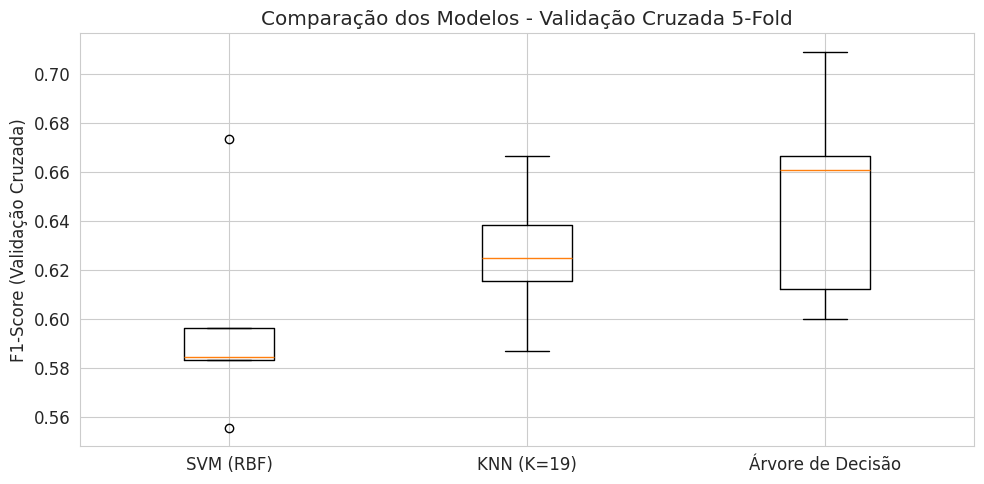

In [19]:
# Validação cruzada com 5 folds
modelos_cv = {
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    f'KNN (K={melhor_k})': KNeighborsClassifier(n_neighbors=melhor_k),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42)
}

print("VALIDAÇÃO CRUZADA (5-Fold)")
print("=" * 60)

resultados_cv = {}
for nome, modelo in modelos_cv.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', modelo)
    ])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
    resultados_cv[nome] = scores
    print(f"{nome:25s}: F1-Score = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Boxplot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
ax.set_ylabel('F1-Score (Validação Cruzada)')
ax.set_title('Comparação dos Modelos - Validação Cruzada 5-Fold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'db_validacao_cruzada.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'db_validacao_cruzada.png')}")
plt.show()

### 5.3 Curvas ROC

  → Gráfico salvo em: ../resultados/db_curvas_roc.png


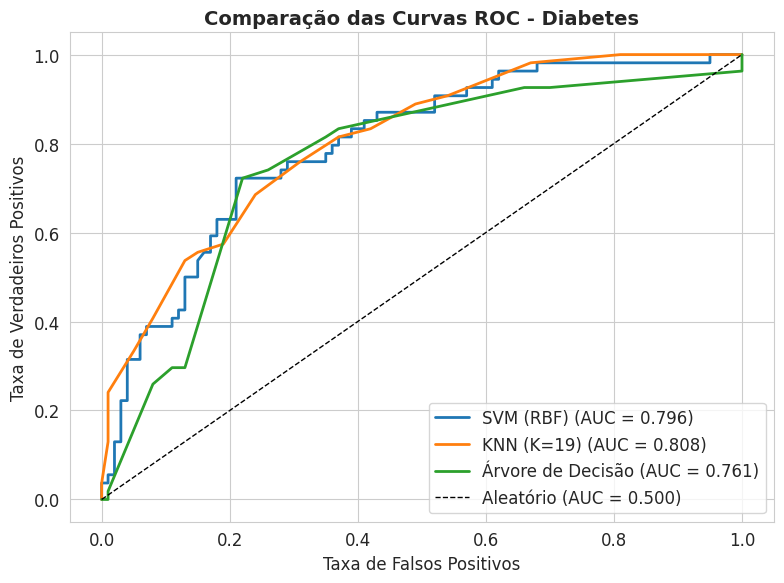

In [20]:
# Curvas ROC comparativas
resultados_roc = {
    'SVM (RBF)': y_prob_svm,
    f'KNN (K={melhor_k})': y_prob_knn,
    'Árvore de Decisão': y_prob_arvore
}

plotar_curvas_roc_comparativas(
    y_teste, resultados_roc,
    titulo='Comparação das Curvas ROC - Diabetes',
    salvar_em=os.path.join(DIR_RESULTADOS, 'db_curvas_roc.png')
)

---

## 6. Interpretação dos Resultados

### 6.1 Feature Importance (Árvore de Decisão)

  → Gráfico salvo em: ../resultados/db_feature_importance.png


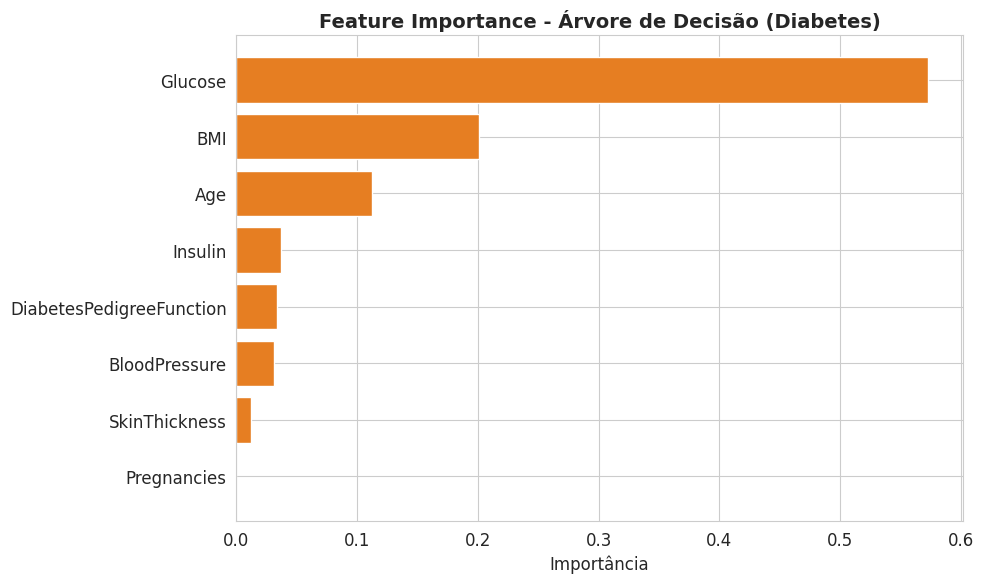

Importância de cada feature:
  1. Glucose                        - 0.5729
  2. BMI                            - 0.2009
  3. Age                            - 0.1120
  4. Insulin                        - 0.0370
  5. DiabetesPedigreeFunction       - 0.0339
  6. BloodPressure                  - 0.0310
  7. SkinThickness                  - 0.0124
  8. Pregnancies                    - 0.0000


In [21]:
# Feature Importance da Árvore de Decisão
feature_names = list(X.columns)
importancias = modelo_arvore.feature_importances_
indices = np.argsort(importancias)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(feature_names)), importancias[indices][::-1], color='#e67e22')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in indices][::-1])
ax.set_xlabel('Importância')
ax.set_title('Feature Importance - Árvore de Decisão (Diabetes)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'db_feature_importance.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'db_feature_importance.png')}")
plt.show()

print("Importância de cada feature:")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]:30s} - {importancias[indices[i]]:.4f}")

### 6.2 SHAP Values

Vamos usar SHAP para entender como cada feature contribui para as predições do modelo de Árvore de Decisão.

SHAP Summary Plot - Árvore de Decisão (Diabetes)
Cada ponto é uma amostra. Vermelho = valor alto, azul = valor baixo.

  → Gráfico salvo em: ../resultados/db_shap_summary.png


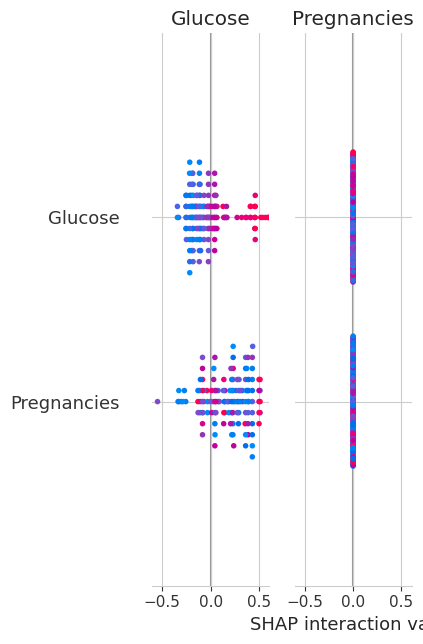

In [22]:
# SHAP para o modelo de Árvore de Decisão
explainer = shap.TreeExplainer(modelo_arvore)
shap_values = explainer.shap_values(X_teste_scaled)

# Summary plot
print("SHAP Summary Plot - Árvore de Decisão (Diabetes)")
print("Cada ponto é uma amostra. Vermelho = valor alto, azul = valor baixo.")
print()

# Para classificação binária
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]  # Classe positiva (diabético)
else:
    shap_values_plot = shap_values

shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=np.array(feature_names),
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'db_shap_summary.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'db_shap_summary.png')}")
plt.show()

  → Gráfico salvo em: ../resultados/db_shap_bar.png


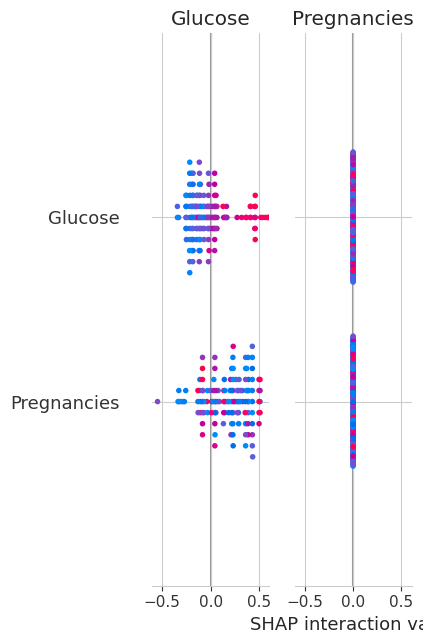

In [23]:
# SHAP Bar Plot
shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=np.array(feature_names),
    plot_type='bar',
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'db_shap_bar.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'db_shap_bar.png')}")
plt.show()

**Interpretação do SHAP:** Como esperado, a **Glucose** é a feature mais importante para a predição de diabetes, seguida por **BMI** e **Age**. Isso é consistente com o conhecimento médico:
- Glicose alta é o principal indicador de diabetes
- Obesidade (BMI alto) é um fator de risco reconhecido
- A incidência de diabetes tipo 2 aumenta com a idade

---

## 7. Discussão Crítica

### O modelo pode ser utilizado na prática?

Os resultados obtidos mostram que é possível construir modelos de ML para auxiliar no diagnóstico de diabetes, embora com desempenho moderado comparado ao dataset de câncer de mama.

**Por que o desempenho é mais modesto neste dataset?**
- O dataset de diabetes é menor (768 amostras vs 569 do câncer de mama)
- As features têm menor poder discriminativo — a separação entre classes é menos clara
- Havia muitos valores faltantes codificados como zero, o que introduz ruído nos dados
- A diabetes é uma doença multifatorial e alguns fatores relevantes podem não estar presentes no dataset

**Pontos fortes do modelo:**
- Glucose, BMI e Age foram confirmados como fatores importantes, alinhado com a literatura médica
- O modelo pode servir como triagem inicial rápida para identificar pacientes de risco

**Limitações:**
- O dataset é composto exclusivamente de mulheres Pima Indians — pode não generalizar para outras populações
- Fatores importantes como histórico familiar detalhado, dieta e atividade física não estão no dataset
- A taxa de falsos negativos pode ser preocupante em um contexto clínico real

**O papel do médico:**
Assim como no caso do câncer de mama, **o médico sempre deve ter a palavra final**. O modelo de ML é uma ferramenta de apoio que pode:
- Automatizar a triagem de pacientes para exames complementares
- Identificar padrões nos dados que podem passar despercebidos
- Priorizar atendimentos de acordo com o risco estimado

Mas jamais deve substituir a avaliação clínica completa, que considera fatores que nenhum modelo tabular consegue capturar.

---

*Notebook desenvolvido como parte do Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs*